# Tarea 2 — Red de Pases del Equipo Local

> Con el mismo evento del ejercicio anterior, crear la red de pases del equipo local (Atlético de Madrid).

**Partido:** Atlético de Madrid 1-0 Barcelona — La Liga 2020/2021 (match_id: `3773656`)

In [1]:
# Importacion de librerias
# matplotlib.pyplot: libreria base para crear figuras y ejes
# numpy: operaciones numericas — concatenacion de arrays y calculo de medias
# mplsoccer.Pitch: dibuja la cancha en orientacion horizontal (estandar para redes de pases)
# mplsoccer.Sbopen: parser de datos StatsBomb integrado en mplsoccer
# pandas: manipulacion de DataFrames para filtrado, groupby y agregacion
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch, Sbopen
import pandas as pd

In [2]:
# Sbopen() instancia el parser de StatsBomb de mplsoccer.
# parser.event() carga todos los eventos del partido y devuelve cuatro DataFrames:
#   df       — flujo principal de eventos (una fila por accion)
#   related  — tabla de relaciones entre eventos conectados
#   freeze   — datos de freeze frame de tiros
#   tactics  — datos de alineacion y formacion por equipo y periodo
# match_id=3773656 es el Atletico de Madrid 1-0 Barcelona
parser = Sbopen()
df, related, freeze, tactics = parser.event(3773656)

In [3]:
# Identificamos el indice de la primera sustitucion del Atletico de Madrid.
# Limitar la red de pases a eventos pre-sustitucion garantiza que la red
# represente solo al once inicial — mezclar jugadores sustitutos distorsiona
# las posiciones promedio y los pesos de las conexiones.
sub = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Atlético Madrid"].iloc[0]["index"]
print(f"Primera sustitucion del Atletico en el indice: {sub}")

# Construimos una mascara booleana para aislar los pases usados en la red:
#   type_name == 'Pass'             — solo eventos de pase
#   team_name == 'Atlético Madrid'  — aislamos al equipo local
#   index < sub                     — excluimos eventos posteriores al primer cambio
#   outcome_name.isnull()           — en el modelo StatsBomb, los pases incompletos tienen
#                                      outcome no nulo; los pases completados tienen outcome nulo
mask_atl = (
    (df.type_name == 'Pass') &
    (df.team_name == "Atlético Madrid") &
    (df.index < sub) &
    (df.outcome_name.isnull())
)

# Proyectamos solo las columnas necesarias para el calculo de la red de pases
df_pass = df.loc[mask_atl, ['x', 'y', 'end_x', 'end_y', "player_name", 'pass_recipient_name']]

# Acortamos los nombres al apellido para reducir el desorden en las etiquetas
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

print(f"Pases completados del Atletico (pre-sustitucion): {len(df_pass)}")
df_pass.head(10)

Primera sustitucion del Atletico en el indice: 3313
Pases completados del Atletico (pre-sustitucion): 386


,x,y,end_x,end_y,player_name,pass_recipient_name
44,75.7,15.6,76.1,8.4,Correa,Sequeira
191,30.4,31.4,28.7,24.1,Correa,Merodio
237,13.8,78.4,23.2,74.3,Savić,Moreno
240,26.1,71.2,29.0,79.2,Moreno,Trippier
243,29.0,79.2,12.4,55.8,Trippier,Vargas
246,13.0,45.6,24.9,47.4,Vargas,Esclapez
254,27.9,75.7,36.8,79.0,Savić,Trippier
258,36.5,79.0,49.0,68.5,Trippier,Moreno
269,63.8,74.3,56.0,68.8,Moreno,Merodio
272,56.6,69.1,56.0,43.9,Merodio,Esclapez


In [4]:
# Calculamos la posicion promedio de cada jugador en la cancha.
# La posicion se estima como el centroide de todas sus coordenadas de toque:
#   - passx/passy: puntos x,y donde el jugador inicio un pase
#   - recx/recy: puntos end_x/end_y donde el jugador recibio un pase
# np.concatenate() une ambos arrays antes de calcular la media con np.mean().
# Esta posicion promedio ponderada por toques refleja la zona de actividad del jugador
# de manera mas precisa que usar solo origenes o solo recepciones.
scatter_df = pd.DataFrame()

for i, name in enumerate(df_pass["player_name"].unique()):
    passx = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    recx = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    recy = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name

    # Centroide de todas las ubicaciones de toque (como pasador y como receptor)
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))

    # Conteo de pases completados por este jugador — usado para codificar el tamano del nodo
    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

# Normalizamos el tamano del nodo relativo al jugador mas activo.
# El jugador con mas pases obtiene marker_size=1500; los demas escalan proporcionalmente.
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)
scatter_df

,player_name,x,y,no,marker_size
0,Correa,77.672549,45.447059,25.0,721.153846
1,Savić,55.101282,63.774359,41.0,1182.692308
2,Moreno,72.972727,62.614545,25.0,721.153846
3,Trippier,78.210417,72.556250,49.0,1413.461538
4,Vargas,47.139655,41.570690,30.0,865.384615
5,Merodio,64.910891,42.985149,52.0,1500.000000
6,Esclapez,64.263830,32.838298,46.0,1326.923077
7,Canseco,48.489655,13.041379,44.0,1269.230769
8,Sequeira,75.522222,23.952778,34.0,980.769231
9,Carrasco,69.282813,9.848437,31.0,894.230769


In [5]:
# Creamos una clave de arista canonica para cada pase ordenando ambos nombres
# alfabeticamente y uniendolos con "_". Ordenar asegura que los pases A->B y B->A
# se cuenten bajo la misma clave, representando el volumen bidireccional total.
df_pass["pair_key"] = df_pass.apply(
    lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1
)

# Agrupamos por pair_key y contamos el numero de pases por par de jugadores.
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x': 'pass_count'}, axis='columns', inplace=True)

# Filtramos pares con mas de 2 pases para eliminar conexiones accidentales.
# Pases aislados pueden reflejar jugadas a balon parado y no relaciones posicionales reales.
lines_df = lines_df[lines_df['pass_count'] > 2]
lines_df.sort_values('pass_count', ascending=False)

,pair_key,pass_count
37,Moreno_Trippier,27
45,Savić_Vargas,26
0,Canseco_Carrasco,24
44,Savić_Trippier,24
27,Esclapez_Sequeira,20
23,Esclapez_Merodio,20
1,Canseco_Esclapez,18
17,Correa_Merodio,15
13,Carrasco_Sequeira,14
2,Canseco_Merodio,13


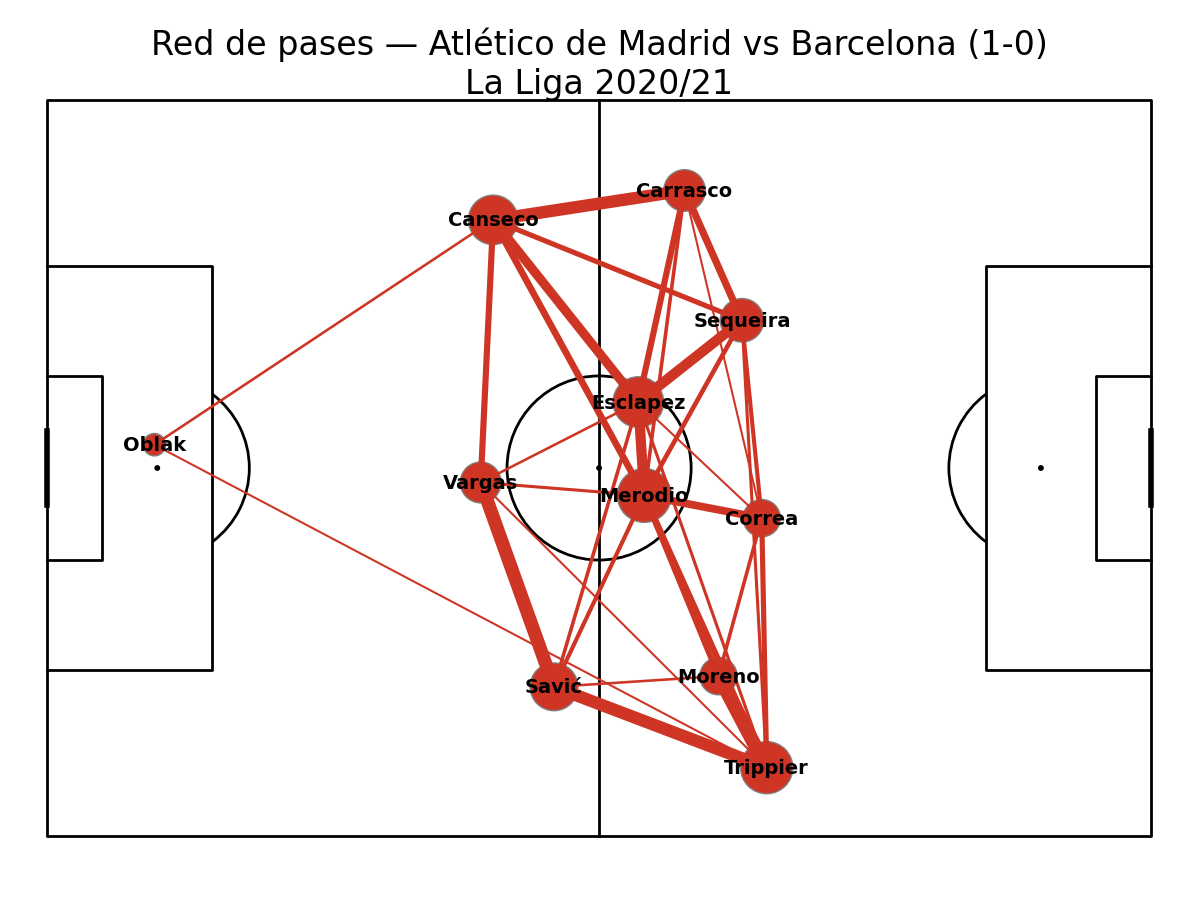

In [6]:
# Dibujamos la red de pases del Atletico de Madrid
# pitch.grid() crea un layout estructurado con ejes separados para:
#   ax["pitch"]   — area principal de la cancha
#   ax["title"]   — zona del titulo
#   ax["endnote"] — zona de nota al pie
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(
    grid_height=0.9, title_height=0.06, axis=False,
    endnote_height=0.04, title_space=0, endnote_space=0
)

# Dibujamos los nodos de jugadores: el tamano codifica el volumen de pases
pitch.scatter(
    scatter_df.x, scatter_df.y,
    s=scatter_df.marker_size,
    color='#CE3524', edgecolors='grey', linewidth=1, alpha=1,
    ax=ax["pitch"]
)

# pitch.annotate() coloca etiquetas de texto en la posicion (x, y) de cada nodo.
# zorder=5 asegura que las etiquetas se rendericen sobre las lineas de conexion (zorder=2).
for i, row in scatter_df.iterrows():
    pitch.annotate(
        row.player_name, xy=(row.x, row.y),
        c='black', va='center', ha='center',
        weight='bold', size=14, ax=ax["pitch"], zorder=5
    )

# Dibujamos las aristas de conexion entre nodos de jugadores.
# Para cada par, buscamos las posiciones promedio de ambos jugadores en scatter_df,
# y trazamos una linea con grosor proporcional a pass_count / max_pass_count.
# El par mas activo obtiene lw=10; los demas escalan proporcionalmente.
for i, row in lines_df.iterrows():
    player1 = row["pair_key"].split("_")[0]
    player2 = row["pair_key"].split("_")[1]

    # Obtenemos la posicion centroide de cada jugador
    player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['x'].iloc[0]
    player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['y'].iloc[0]
    player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['x'].iloc[0]
    player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['y'].iloc[0]
    num_passes = row["pass_count"]

    # Normalizamos el grosor de linea: el par con mas pases obtiene lw=10
    line_width = (num_passes / lines_df["pass_count"].max() * 10)
    pitch.lines(
        player1_x, player1_y, player2_x, player2_y,
        alpha=1, lw=line_width, zorder=2, color='#CE3524',
        ax=ax["pitch"]
    )

fig.suptitle("Red de pases — Atlético de Madrid vs Barcelona (1-0)\nLa Liga 2020/21", fontsize=24)
plt.show()

## Analisis de la red de pases

La red de pases del Atletico de Madrid en este partido revela un patron muy diferente al de equipos de posesion:

1. **Bloque compacto y retrasado:** Las posiciones promedio de los jugadores estan concentradas en la mitad propia del campo, lo que refleja el bloque bajo defensivo clasico de Simeone. Los centrales y laterales se situan en zonas profundas.

2. **Conexiones cortas entre la defensa:** Las lineas mas gruesas se encuentran entre los defensores centrales y el pivote defensivo, indicando una circulacion de balon horizontal en la zona de seguridad. El Atletico no busca dominar la posesion sino mantener la estructura.

3. **Koke como conector:** Koke tipicamente actua como el jugador que mas conecta la defensa con el ataque, siendo el nodo con mas conexiones diversas en la red.

4. **Pocos pases hacia arriba:** Las conexiones hacia los jugadores mas adelantados (Joao Felix, Carrasco) son mas finas, lo que indica que el equipo no buscaba pases progresivos constantes sino que esperaba momentos puntuales de transicion.

5. **Red asimetrica por bandas:** Carrasco en la banda izquierda puede mostrar mas conexiones que el extremo derecho, reflejando la preferencia del Atletico de salir en transicion por esa zona.

**Conclusion:** La red de pases del Atletico confirma su identidad tactica: un equipo que cede la posesion al rival, se agrupa en un bloque bajo compacto, y utiliza pases cortos de seguridad entre la defensa y el mediocampo. Las transiciones ofensivas son rapidas y directas, con pocos pases intermedios, lo que se traduce en lineas finas hacia los jugadores de ataque.